TODO: Cambiar `price_grid_from_samples` y `discrete_probs_from_samples` (legacy) por sus actualizaciones: `grid_and_prob_matrix`

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

from itertools import product
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import SPSA

from quantum_cva.mc_benchmark.benchmark_utils import (
    simulate_S,
    price_grid_from_samples,
    discrete_probs_from_samples,
    )
from quantum_cva.state_prep.qcbm.target_distribution import build_joint_target_from_P_bin
from quantum_cva.state_prep.qcbm.qcbm_circuit import MLQcbmCircuit
from quantum_cva.circuit_training_tools import (
    minimize_with_cost_history,
    plot_training_diagnostics
    )
from quantum_cva.state_prep.qcbm.train_utils import (
    save_qcbm_distributions
    )
# from quantum_cva.cross_validation_utils import SPSAHyperparamCV


In [2]:
# Root to data folder 
from pathlib import Path
import quantum_cva
import json

REPO_ROOT = Path(quantum_cva.__file__).resolve().parents[2]
OUT_DIR = REPO_ROOT / "data" / "qcbm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Loading target probability distribution $p_{tg}(x)$ (clasically computed)

In [3]:
# Discretization parameters
n = 2
m = 2
N = 2**n  # number of price bins
M = 2**m  # number of time steps

In [4]:
# ============================================================
# 0) Reproducibility
# ============================================================
np.random.seed(123)
 
# ============================================================
# 1) Simulate S(t) paths
# ============================================================

# Simulation parameters
S0 = 5.0
K = 5.5
sigma = 0.25
r = 0.02

# Fine time grid
T = 184/360
N_paths = 100_000
M_fine = 8 # diary steps
t = np.linspace(0.0, T, M_fine+1)

# Simulate paths
n_paths = 10000
Z = np.random.standard_normal(size=(n_paths, M_fine))

# simulate_S returns M+1 arrays (including t=0 with S0)
# Use S_by_time[1:] when only future times (t>0) are needed
S_by_time = simulate_S(
    S0=S0, mu=r, sigma=sigma, t=t, Z=Z,
    antithetic=True,
    moment_match=False,
    replications=100,
    replication_seed=12345,
    pathwise=True
)

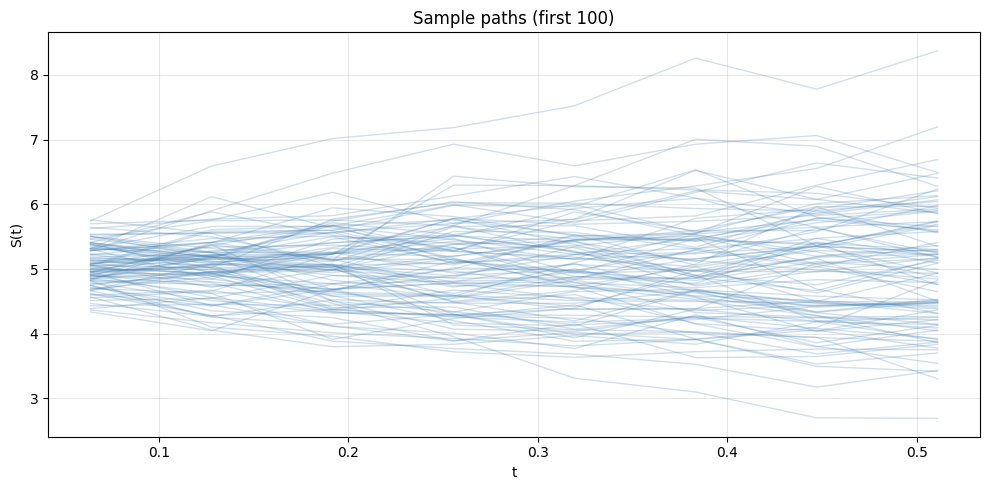

In [5]:
# Plot some sample paths and histogram at T
# Use S_by_time[1:] to exclude t=0 (deterministic S0)
n_plot = 100
S_plot = np.vstack([s[:n_plot] for s in S_by_time[1:]])

plt.figure(figsize=(10, 5))
for k in range(n_plot):
    plt.plot(t[1:], S_plot[:, k], color="steelblue", alpha=0.25, linewidth=1.0)
plt.title("Sample paths (first 100)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 2) Discretize prices: choose n so that N=2^n bins (power of two)
# ============================================================
n_sigma = 3.0

# Use S_by_time[1:] to exclude t=0 (only future exposure dates)
edges, grid_info = price_grid_from_samples(S_by_time[1:], n=n, n_sigma=n_sigma)
print("Grid info:", grid_info)
print("edges length:", len(edges), "=> N bins:", len(edges) - 1)
assert (len(edges) - 1) == N

Grid info: [3.00208    4.36835587 5.73463174 7.10090761]
edges length: 5 => N bins: 4


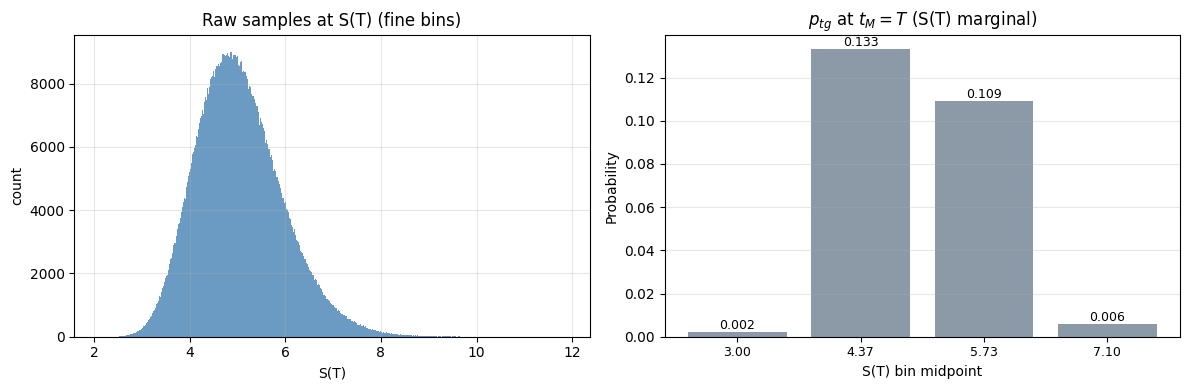

In [7]:
# ============================================================
# 2b) Histogram: raw vs discretized prices (loss of resolution)
# ============================================================
# S_by_time[-1] is S(T), the final exposure date
samples = S_by_time[-1]

# Raw histogram (fine bins)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(samples, bins=1000, color="steelblue", alpha=0.8)
axes[0].set_title("Raw samples at S(T) (fine bins)")
axes[0].set_xlabel("S(T)")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

# ============================================================
# Build the JOINT target distribution p_tg(i,j) that will be used for QCBM training
# Show only the LAST M time step (t_M = T), which corresponds to S(T)
# ============================================================
# Build P_bin for ALL times (same as in cell 3)
_P_bin = np.zeros((M, N), dtype=float)
for i in range(M):
    _P_bin[i, :] = discrete_probs_from_samples(S_by_time[i + 1], edges)

# Build joint: p_tg(i,j) = P(t_i) * P(s_j|t_i), with P(t_i) = 1/M (uniform)
_joint = (1.0 / M) * _P_bin  # shape (M, N)
_ptg = _joint.reshape(M * N)  # flatten in time_major order

# Extract the last N elements (corresponding to t_M = T)
# In time_major order: x = i*N + j, so last time step i=M-1 corresponds to x in [(M-1)*N, M*N)
ptg_T = _ptg[(M-1)*N : M*N]  # shape (N,) - probabilities at S(T)

# Use s_mid (bin centers) as x-axis labels
s_mid = grid_info  # grid_info is s_mid from price_grid_from_samples
x_pos = np.arange(N)
axes[1].bar(x_pos, ptg_T, color="slategray", alpha=0.8)
axes[1].set_title(r"$p_{tg}$ at $t_M = T$ (S(T) marginal)")
axes[1].set_xlabel("S(T) bin midpoint")
axes[1].set_ylabel("Probability")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"{v:.2f}" for v in s_mid], fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

# Annotate each bin with its probability
for xp, prob in zip(x_pos, ptg_T):
    if prob > 0.001:
        axes[1].annotate(f"{prob:.3f}", (xp, prob), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 3) Build conditional distributions P_bin[i,:] = P(s_bin | t_i)
# ============================================================
# S_by_time[1:] contains S(t_1), ..., S(t_M) (excluding t=0)
P_bin = np.zeros((M, N), dtype=float) 
for i in range(M):
    # S_by_time[i+1] corresponds to time t_{i+1} (i=0 -> t_1, etc.)
    P_bin[i, :] = discrete_probs_from_samples(S_by_time[i + 1], edges)

assert P_bin.shape == (M, N)
assert np.all(P_bin >= -1e-15)
assert np.allclose(P_bin.sum(axis=1), 1.0, atol=1e-10)
print("P_bin OK. shape:", P_bin.shape)

P_bin OK. shape: (4, 4)


In [9]:
# ============================================================
# 4) Build joint target for QCBM 
#    p_tg(i,j) = P(t_i) P(s_j|t_i), with uniform P(t_i)=1/M by default
# ============================================================
tgt = build_joint_target_from_P_bin(P_bin, order="time_major") 

print("\n--- Joint target summary ---")
print(f"M={tgt.M} (m={tgt.m} qubits), N={tgt.N} (n={tgt.n} qubits)")
print("len(p_tg) =", tgt.p_tg.size, "(expected M*N =", tgt.M * tgt.N, ")")
print("sum(p_tg) =", tgt.p_tg.sum())

assert tgt.M == M
assert tgt.N == N
assert tgt.p_tg.ndim == 1
assert tgt.p_tg.size == M * N
assert abs(tgt.p_tg.sum() - 1.0) < 1e-12


--- Joint target summary ---
M=4 (m=2 qubits), N=4 (n=2 qubits)
len(p_tg) = 16 (expected M*N = 16 )
sum(p_tg) = 1.0


Joint target distribution:
$$
p_{tg}(x),
$$
a flatten vector with $2^{n + m}$ elements. So the register $x$ is written in the computational basis of $n + m$ qubits.

In [10]:
# ============================================================
# Print all computational basis states directly from p_tg
# ============================================================
# Sanity check: check dimensions of tgt are correct
ptg = tgt.p_tg
m = tgt.m      # time qubits
n = tgt.n      # price qubits
M = tgt.M
N = tgt.N

def to_bits(x, L):
    return format(x, f"0{L}b")

print("Probability distribution over computational basis states (quantum - friendly):")

for x, prob in enumerate(ptg):
    # Binary representation of the full register
    bits = to_bits(x, m + n)

    # Decode indices according to time_major convention
    i = x // N          # time index
    j = x % N           # price-bin index

    bits_time  = bits[:m]
    bits_price = bits[m:]

    print(
        f"|{bits}>  "
        f"(t_{i+1}, s_{j})  "
        f"P = {prob:.6e}"
    )

Probability distribution over computational basis states (quantum - friendly):
|0000>  (t_1, s_0)  P = 3.750000e-07
|0001>  (t_1, s_1)  P = 1.422310e-01
|0010>  (t_1, s_2)  P = 1.077594e-01
|0011>  (t_1, s_3)  P = 9.250000e-06
|0100>  (t_2, s_0)  P = 8.212504e-05
|0101>  (t_2, s_1)  P = 1.377963e-01
|0110>  (t_2, s_2)  P = 1.115069e-01
|0111>  (t_2, s_3)  P = 6.146253e-04
|1000>  (t_3, s_0)  P = 7.105202e-04
|1001>  (t_3, s_1)  P = 1.355324e-01
|1010>  (t_3, s_2)  P = 1.110660e-01
|1011>  (t_3, s_3)  P = 2.691077e-03
|1100>  (t_4, s_0)  P = 2.103859e-03
|1101>  (t_4, s_1)  P = 1.332534e-01
|1110>  (t_4, s_2)  P = 1.089256e-01
|1111>  (t_4, s_3)  P = 5.717190e-03


---

## QCBM ansatz definition & training

In [11]:
# Rename discretization variables to enhance quantum readability
num_qubits_price = n
num_qubits_time = m
num_qubits = num_qubits_price + num_qubits_time

In [12]:
# Ansatz definition
EPS_COST = 1e-12

qcbm = MLQcbmCircuit(n_qubits=num_qubits, n_layers=2, name="G_p")  
qc, theta = qcbm.qc, qcbm.theta

print(qc.draw(output="text", fold=120))
print("n_layers:", qcbm.n_layers)
print("n_params:", qcbm.n_params)

     ┌──────────────┐┌──────────────┐┌────────────────┐┌────────────────┐┌─────────────────┐                   »
q_0: ┤ Rx(theta[0]) ├┤ Rz(theta[1]) ├┤0               ├┤0               ├┤0                ├───────────────────»
     ├──────────────┤├──────────────┤│  Rxx(theta[8]) ││                ││                 │┌─────────────────┐»
q_1: ┤ Rx(theta[2]) ├┤ Rz(theta[3]) ├┤1               ├┤  Rxx(theta[9]) ├┤                 ├┤0                ├»
     ├──────────────┤├──────────────┤└────────────────┘│                ││  Rxx(theta[10]) ││  Rxx(theta[11]) │»
q_2: ┤ Rx(theta[4]) ├┤ Rz(theta[5]) ├──────────────────┤1               ├┤                 ├┤1                ├»
     ├──────────────┤├──────────────┤                  └────────────────┘│                 │└─────────────────┘»
q_3: ┤ Rx(theta[6]) ├┤ Rz(theta[7]) ├────────────────────────────────────┤1                ├───────────────────»
     └──────────────┘└──────────────┘                                    └─────────────────┘    

### Ideal Probability Evaluation vs. Shot-Based Estimation

In variational quantum algorithms such as Quantum Circuit Born Machines (QCBMs), the model distribution is defined by the Born probabilities of a parameterized quantum circuit. There are two conceptually distinct ways of accessing these probabilities: the *ideal (statevector)* evaluation and the *shot-based* estimation. Although both originate from the same underlying quantum state, they differ fundamentally in how probabilities are obtained and in the presence of statistical noise.


<br>


In the **ideal *(statevector)* setting**, the parameterized circuit $U(\theta)$ is applied to the computational basis state $|0\cdots 0\rangle$, and the full quantum state is computed exactly:
$$
|\psi(\theta)\rangle = U(\theta)\,|0\cdots 0\rangle
= \sum_{x \in \{0,1\}^n} a_x(\theta)\,|x\rangle .
$$

All complex amplitudes $a_x(\theta)$ are explicitly available. The model probabilities are then obtained deterministically as

$$
\boxed{
p_\theta(x) = |a_x(\theta)|^2 \quad \text{for all } x .
}
$$


This procedure involves no sampling and no measurement. The resulting probability vector is exact, the loss function is deterministic, and repeated evaluations at the same parameters $\theta$ always return the same value. This regime is accessible only in classical simulation and serves as an idealized reference for analysis and debugging.


<br>

In contrast, while working in a ***shot-based* setting**, the circuit is followed by measurements in the computational basis. Each execution (shot) produces a single bitstring outcome
$$
X \in \{0,1\}^n,
$$
distributed according to the Born rule:
$$
\mathbb{P}(X = x) = |a_x(\theta)|^2 .
$$

Repeating the experiment $N_{\text{shots}}$ times yields independent and identically distributed samples $X_1, \dots, X_{N_{\text{shots}}}$. The probabilities are then estimated empirically via relative frequencies,

$$
\boxed{
\hat p_\theta(x) = \frac{1}{N_{\text{shots}}}
\sum_{k=1}^{N_{\text{shots}}} \mathbf{1}_{\{X_k = x\}} .
}
$$

The resulting estimator is unbiased,
$$
\mathbb{E}[\hat p_\theta(x)] = p_\theta(x),
$$
but exhibits statistical fluctuations with variance
$$
\mathrm{Var}[\hat p_\theta(x)] =
\frac{p_\theta(x)\bigl(1 - p_\theta(x)\bigr)}{N_{\text{shots}}}.
$$

Consequently, any cost function built from $\hat p_\theta$ is inherently noisy, and its evaluation varies from call to call even at fixed parameters.

In the limit $N_{\text{shots}} \to \infty$, the shot-based estimator converges to the ideal probabilities, but for any finite number of shots, statistical noise is unavoidable. This difference has direct consequences for optimization, as noise-free objective functions are fundamentally easier to minimize than their stochastic counterparts.

#### 1. Estimation under the ideal (*statevector*) setting.

Hyperparameters of the training

In [83]:
# ---- fixed hyperparams / reproducibility ----
theta_seed = 355
N_ITERS = 7000
RHOBEG = 0.5
METHOD = "COBYLA"

rng = np.random.default_rng(theta_seed)
x0 = rng.standard_normal(len(theta)).astype(float)

Optimization (Training) of the quantum circuit

In [84]:
# Define cost function
cost = qcbm.cost_fn(ptg, eps=EPS_COST)

# Run the optimization
res, cost_history = minimize_with_cost_history(
    cost,
    x0=x0,
    minimize_fn=minimize,
    method=METHOD,
    options={"maxiter": int(N_ITERS), 
             "rhobeg": RHOBEG,
             "disp": True},
)

theta_star = np.asarray(res.x, dtype=float)

# ------ Probabilities: p0 -> before training, p_star -> after training ------ 
p0 = qcbm.probabilities(x0)
p_star = qcbm.probabilities(theta_star)
# ----------------------------------------------------------------------------

print("success:", res.success)
print("message:", res.message)
print("nfev:", getattr(res, "nfev", None), "nit:", getattr(res, "nit", None))
print("final cost:", float(res.fun))

success: False
message: Maximum number of function evaluations has been exceeded.
nfev: 7000 nit: None
final cost: 2.1296581258914205


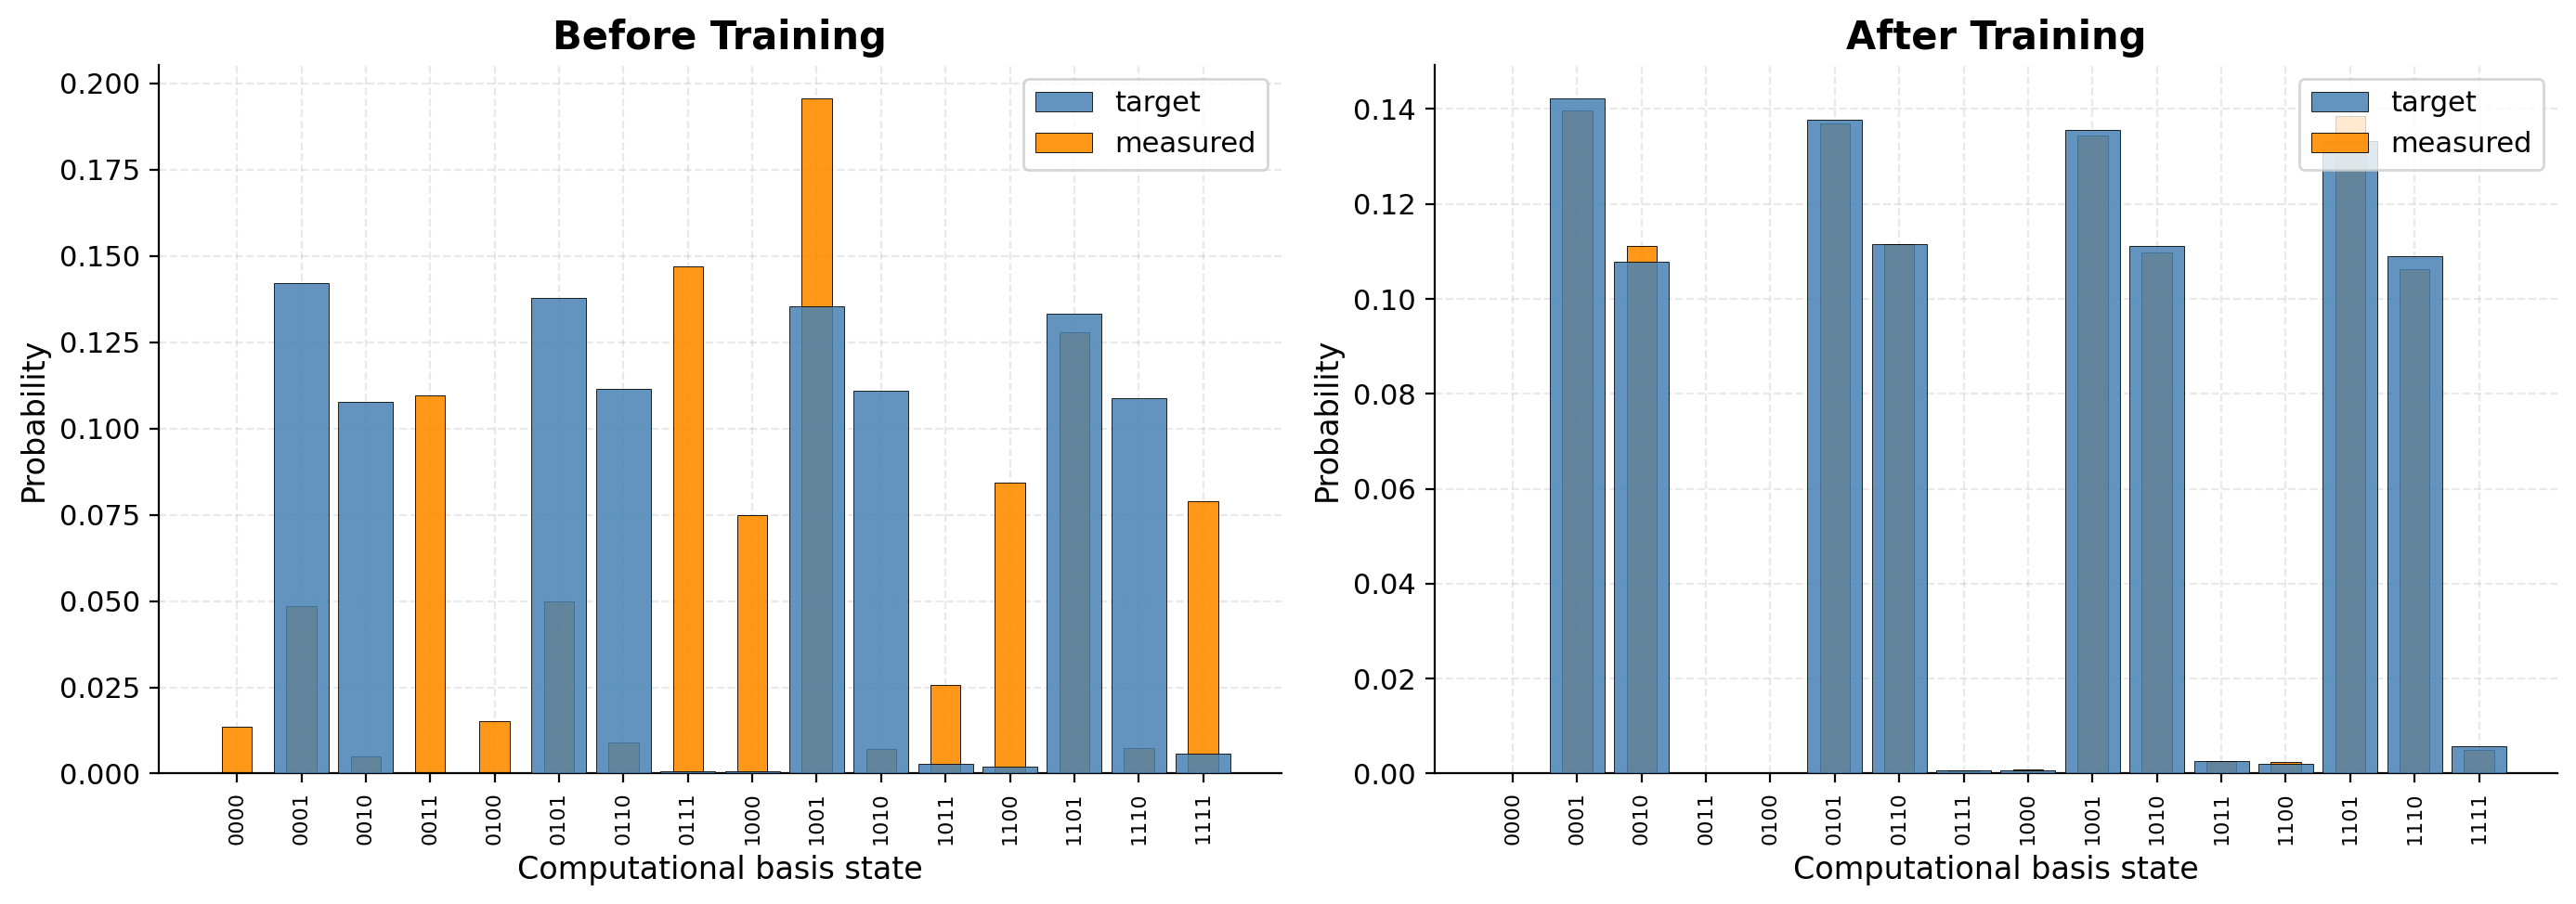

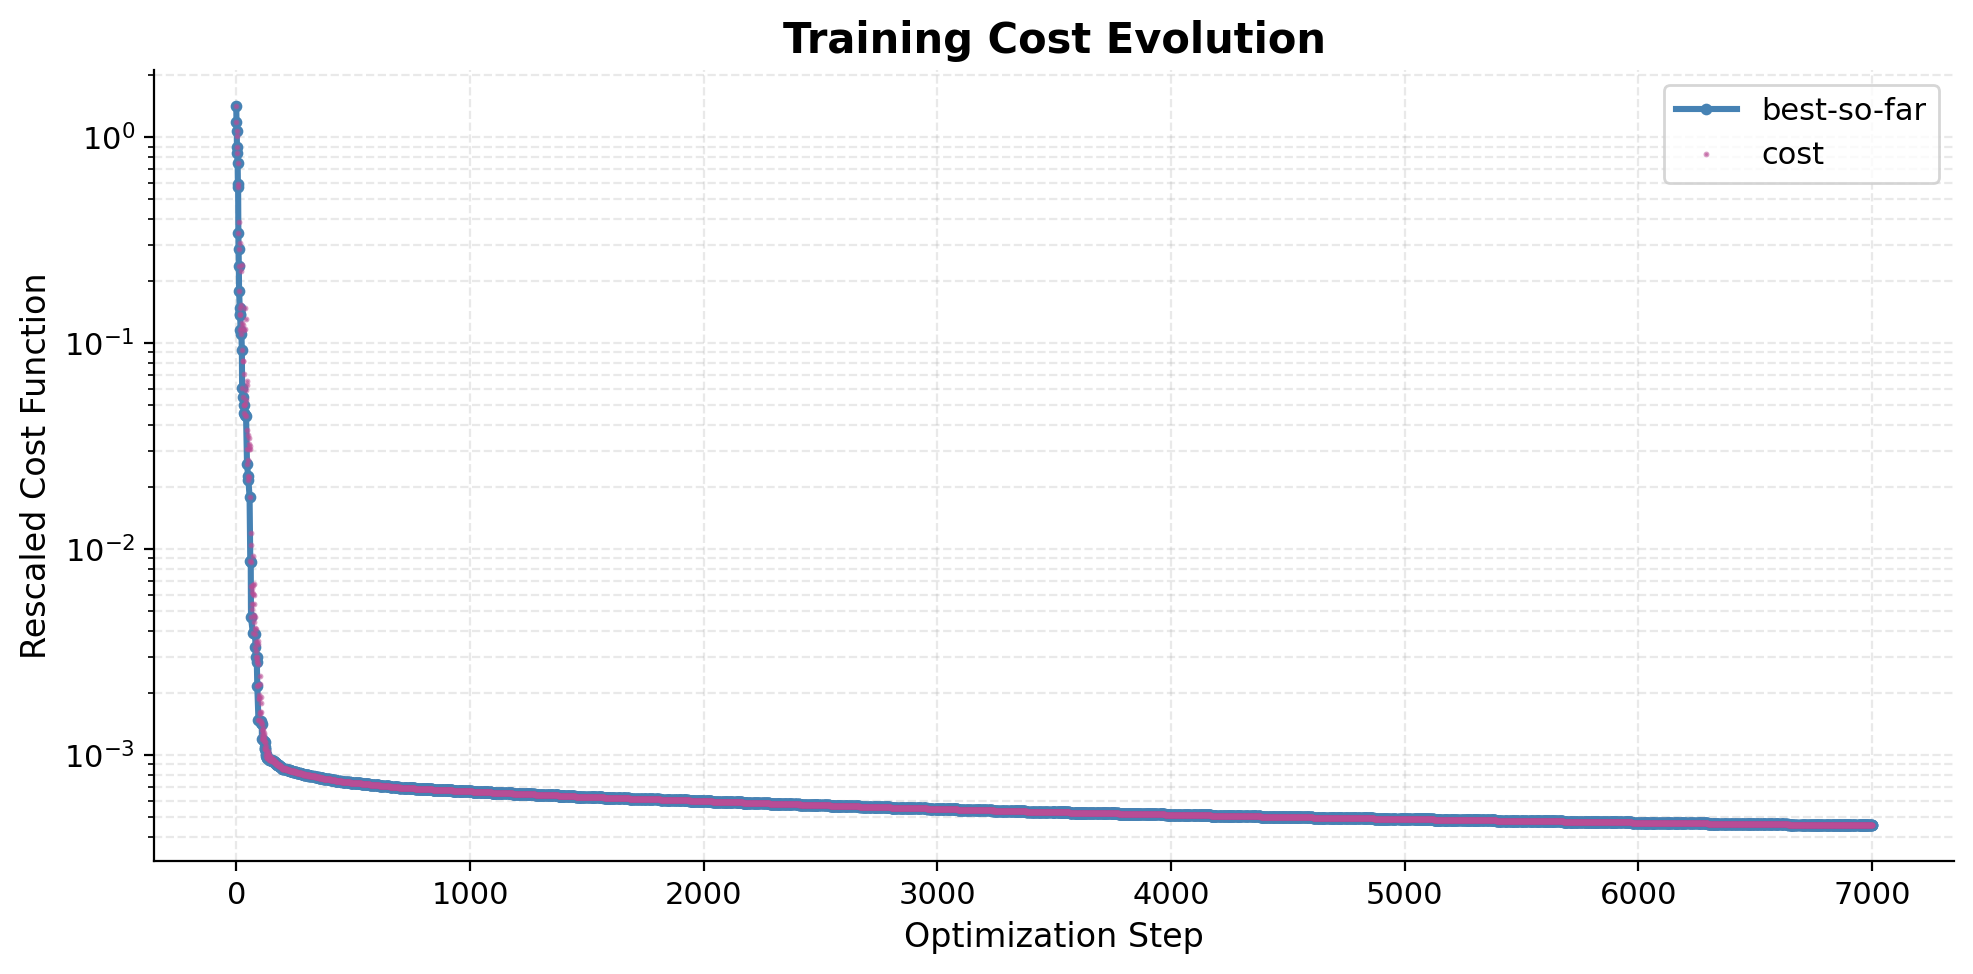


=== 'FIT' METRIC + OTHERS ===
KL(ptg || p*)  = 0.0004540812175946136
L1             = 0.01857220420004244
TV = 0.5*L1    = 0.00928610210002122
Linf           = 0.005206557012884777

=== 4x4 MATRICES (rows=t_i, cols=s_j) ===
ptg:

[3.75000000e-07 1.42231000e-01 1.07759375e-01 9.25000000e-06
 8.21250411e-05 1.37796319e-01 1.11506931e-01 6.14625307e-04
 7.10520250e-04 1.35532363e-01 1.11066040e-01 2.69107670e-03
 2.10385889e-03 1.33253398e-01 1.08925553e-01 5.71718995e-03]

p_star:

[3.44227597e-05 1.39671643e-01 1.11188615e-01 1.10216169e-04
 1.92701029e-04 1.36879019e-01 1.11478971e-01 5.86660359e-04
 8.53759991e-04 1.34464464e-01 1.09767643e-01 2.68761813e-03
 2.36533402e-03 1.38459955e-01 1.06272074e-01 4.98690301e-03]


In [85]:
# --- Cost function rescaling: ideal value ~ 0 ---
C_star = -np.sum(ptg * np.log(np.maximum(ptg, EPS_COST)))
rescaled = cost_history - C_star
rescaled_plot = np.maximum(rescaled, 1e-12)          # for semilogy
best_so_far = np.minimum.accumulate(rescaled_plot)

tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

fig_dist, fig_cost = plot_training_diagnostics(
    target=ptg,
    before=p0,
    after=p_star,
    cost_history=rescaled_plot,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=[format(i, f"0{qcbm.n_qubits}b") for i in range(qcbm.dim)] # computational basis labels
) 
plt.show()

ms = qcbm.metrics(ptg, p_star)

print("\n=== 'FIT' METRIC + OTHERS ===")
print("KL(ptg || p*)  =", float(ms["kl"]))
print("L1             =", float(ms["l1"]))
print("TV = 0.5*L1    =", float(ms["tv"]))
print("Linf           =", float(ms["linf"]))

print("\n=== 4x4 MATRICES (rows=t_i, cols=s_j) ===")
print("ptg:\n")
print(ptg)
print("\np_star:\n")
print(p_star)

In [ ]:
# save output of the *statevector* training and metadata for reproducibility
npz_path, json_path = save_qcbm_distributions(
    qcbm=qcbm,
    p_trained=p_star,
    p_target=ptg,
    filename_stem="qcbm_output_distribution_statevector",
    metadata={"optimizer": METHOD, "RHOBEG": RHOBEG, "seed": theta_seed, "n_iters": N_ITERS},
)



Some graphics for enhanced visualization. Execute this code:


plot_joint_and_marginals(
    ptg=ptg,
    p_star=p_star,
    M=M,
    N=2**n,
    order="time_major",
    title_suffix="4x4",
)


---

#### 2. Estimation under the *shot-based* setting

We perform first a cross-validation of the hyperparameters of the optimizer to select the ones that work best in this shot setting. We'll use the SPSA optimizer - Simultaneous Perturbation Stochastic Algorithm - that is known to work better in noisy regimes.

This problem presents high sensibility to initial conditions. In fact, the choice of the initial seed is very important. List of seeds that work well below:
- `seed` = 355: Very good perfomance
- `seed` = 150: Finds a plateau in 1500 iters aprox, cannot go behind 10^-2.

The hyperparameters of the optimization have been chosen by perfoming a cross-validation analysis previously, using the `SPSAHyperparamCV` class. Now, we explain the optimization procedure that has been followed.


When we set `shots = N`, the objective becomes **measurement-based**: each call to the circuit returns a finite-sample estimate $\hat p_\theta$ of the true Born distribution $p_\theta$. Therefore the cost
$$
\widehat{\mathrm{CE}}(p_{\mathrm{tg}}, \hat p_\theta) = -\sum_j p_{\mathrm{tg}}(j)\,\log \hat p_\theta(j)
$$
is **stochastic** (it fluctuates from call to call). The `seed` controls the pseudo-random number generator of the simulator only; real hardware does not have a “seed”.

Below are three common strategies to handle this stochasticity when training with SPSA.



##### (A) Deterministic objective (fixed seed everywhere)
**Idea:** Use a fixed simulator seed for every evaluation, so the same $x$ always produces the same sampled counts.

**Pros**
- Fully reproducible runs (useful for debugging and unit tests).
- Objective looks nearly deterministic to the optimizer.

**Cons (hardware mismatch)**
- Unrealistic: hardware measurements cannot be “replayed” by fixing a seed.
- Risk of learning simulator-specific sampling artifacts (the optimizer can over-adapt to one particular pseudo-random stream).

**When to use**
- Debugging, regression tests, quick ablations.



##### (B) Realistic objective (no seed / fresh randomness each call)  ✅ *what we use*
**Idea:** Do not fix any seed (or vary it unpredictably), so each evaluation mimics an independent measurement run.

**Pros (hardware-aligned)**
- Matches hardware behavior: every circuit execution yields new measurement outcomes with multinomial noise.
- SPSA is designed to tolerate stochastic objectives and noisy gradient estimates.
- With large `shots` and averaging (`resamplings`), the optimization becomes stable while remaining realistic.

**Cons**
- Not bitwise reproducible (two runs may differ).
- Higher variance in the objective and gradient estimates; convergence can be slower if `shots` are too low.

**Why we choose this for hardware realism**
On real quantum devices, the dominant training noise comes from finite sampling and device noise. There is **no notion of a simulator seed**, so the most faithful simulation is to allow **fresh measurement randomness** at each call. We then control variance in a hardware-compatible way:
- increase `shots` (reduces sampling noise),
- use `resamplings > 1` (averages SPSA gradient estimates),
- use Dirichlet/Laplace smoothing to avoid $\log(0)$ issues in sparse outcomes.



##### (C) Common random numbers per iteration (seed shared within SPSA pair, varied across iterations)
**Idea:** For each SPSA iteration, use the **same seed** for the pair $x+\Delta$ and $x-\Delta$ (to reduce variance in the difference), but change the seed between iterations.

**Pros**
- Strong variance reduction for SPSA gradient estimates (more stable updates).
- Still closer to hardware than (A) if the seed is varied over time.

**Cons (hardware mismatch)**
- Still uses a simulator-only control knob.
- Requires additional plumbing: the seed must change at the iteration level (not a fixed closure parameter).

**When to use**
- Simulator experiments where you want stability close to the hardware regime but with extra variance reduction.



##### Summary (hardware perspective)
For preparing a pipeline that will later run on real hardware, we prefer **(B)** because it preserves the key feature of hardware execution: **each circuit call is a fresh stochastic measurement**. We manage noise using shot budgets, resampling, and smoothing—tools that remain valid once we move from simulator to device.


In [ ]:
rng = np.random.default_rng(theta_seed)
x0 = rng.standard_normal(len(theta)).astype(float)

In [ ]:
N_ITERS = 2500              # Increased iterations for better convergence
SHOTS   = 5000             # Increased shots for lower variance

# Tuned hyperparams for SPSA (minimized for KL divergence)
LR   = 0.007           # Low learning rate for stability
PERT = 0.07             # Small perturbation for finer gradients
eps = float(1e-9)

# -------------------------
# Cost function (shot-based)
# -------------------------
cost_shots = qcbm.cost_fn(
    ptg,
    eps=eps,
    shots=SHOTS,
    seed=None,
    rescaled=True,
    smoothing="dirichlet",  # Add smoothing for numerical stability
)

# -------------------------
# Plain SPSA run (store best theta)
# -------------------------
theta0 = np.asarray(x0, dtype=float).copy()

cost_history: list[float] = []
best = {"fx": float("inf"), "x": theta0.copy()}

def cb(nfev, x, fx, stepsize, accepted):
    fx = float(fx)
    cost_history.append(fx)
    if fx < best["fx"]:
        best["fx"] = fx
        best["x"] = np.asarray(x, dtype=float).copy()

opt = SPSA(
    maxiter=int(N_ITERS),
    learning_rate=LR,
    perturbation=PERT,
    resamplings=3,          # Average gradient estimates for robustness
    blocking=False,         # Allow updates
    callback=cb,
    trust_region=True,
    regularization=0.1
)

_t0 = time.perf_counter()
res = opt.minimize(fun=cost_shots, x0=theta0)
_spsa_time = time.perf_counter() - _t0

theta_last = np.asarray(res.x, dtype=float)
theta_best = best["x"].copy()

print(f"Training complete. Best cost observed: {best['fx']:.6f}")
print(f"SPSA optimization time (s): {_spsa_time:.2f}")


Training complete. Best cost observed: 0.000813
SPSA optimization time (s): 210.42


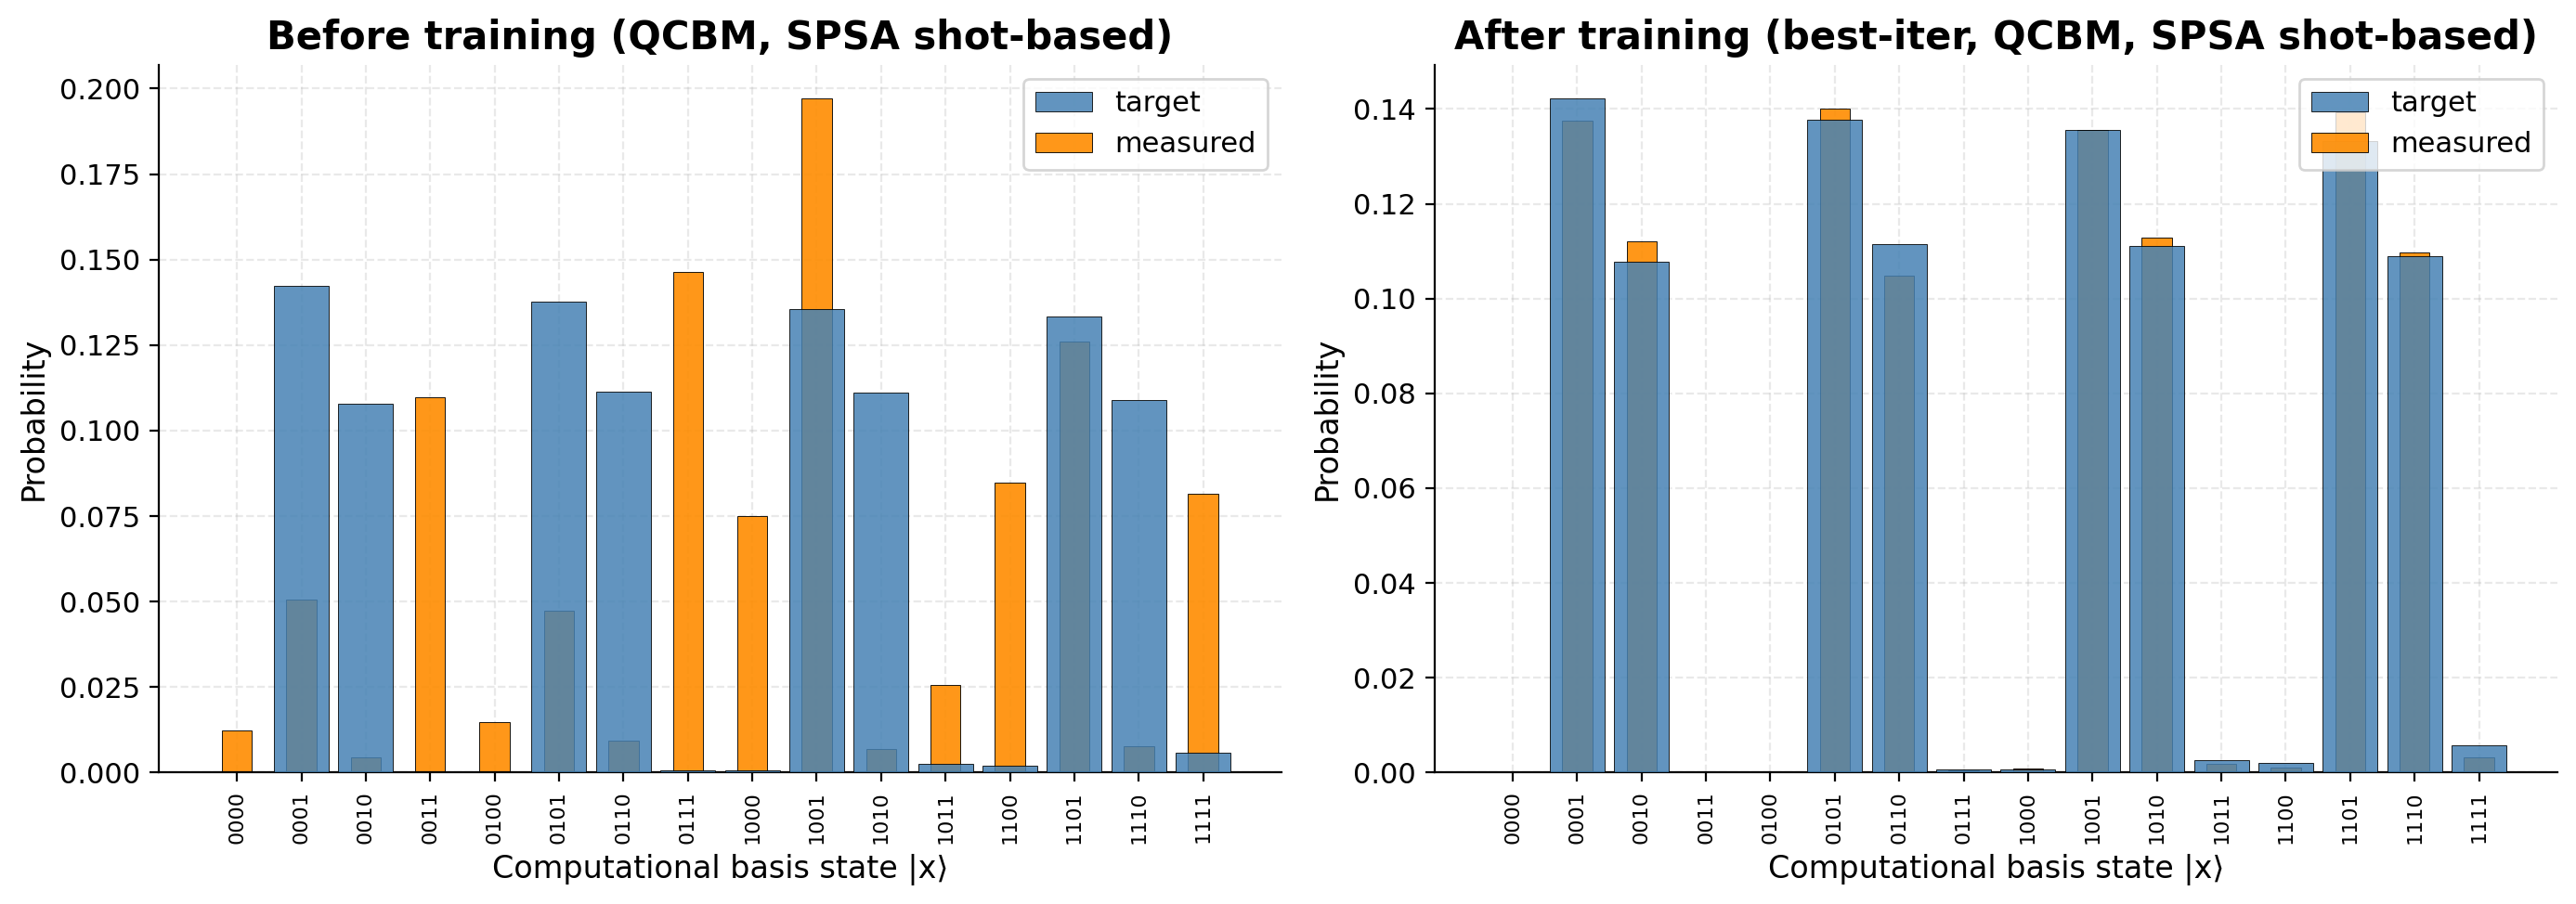

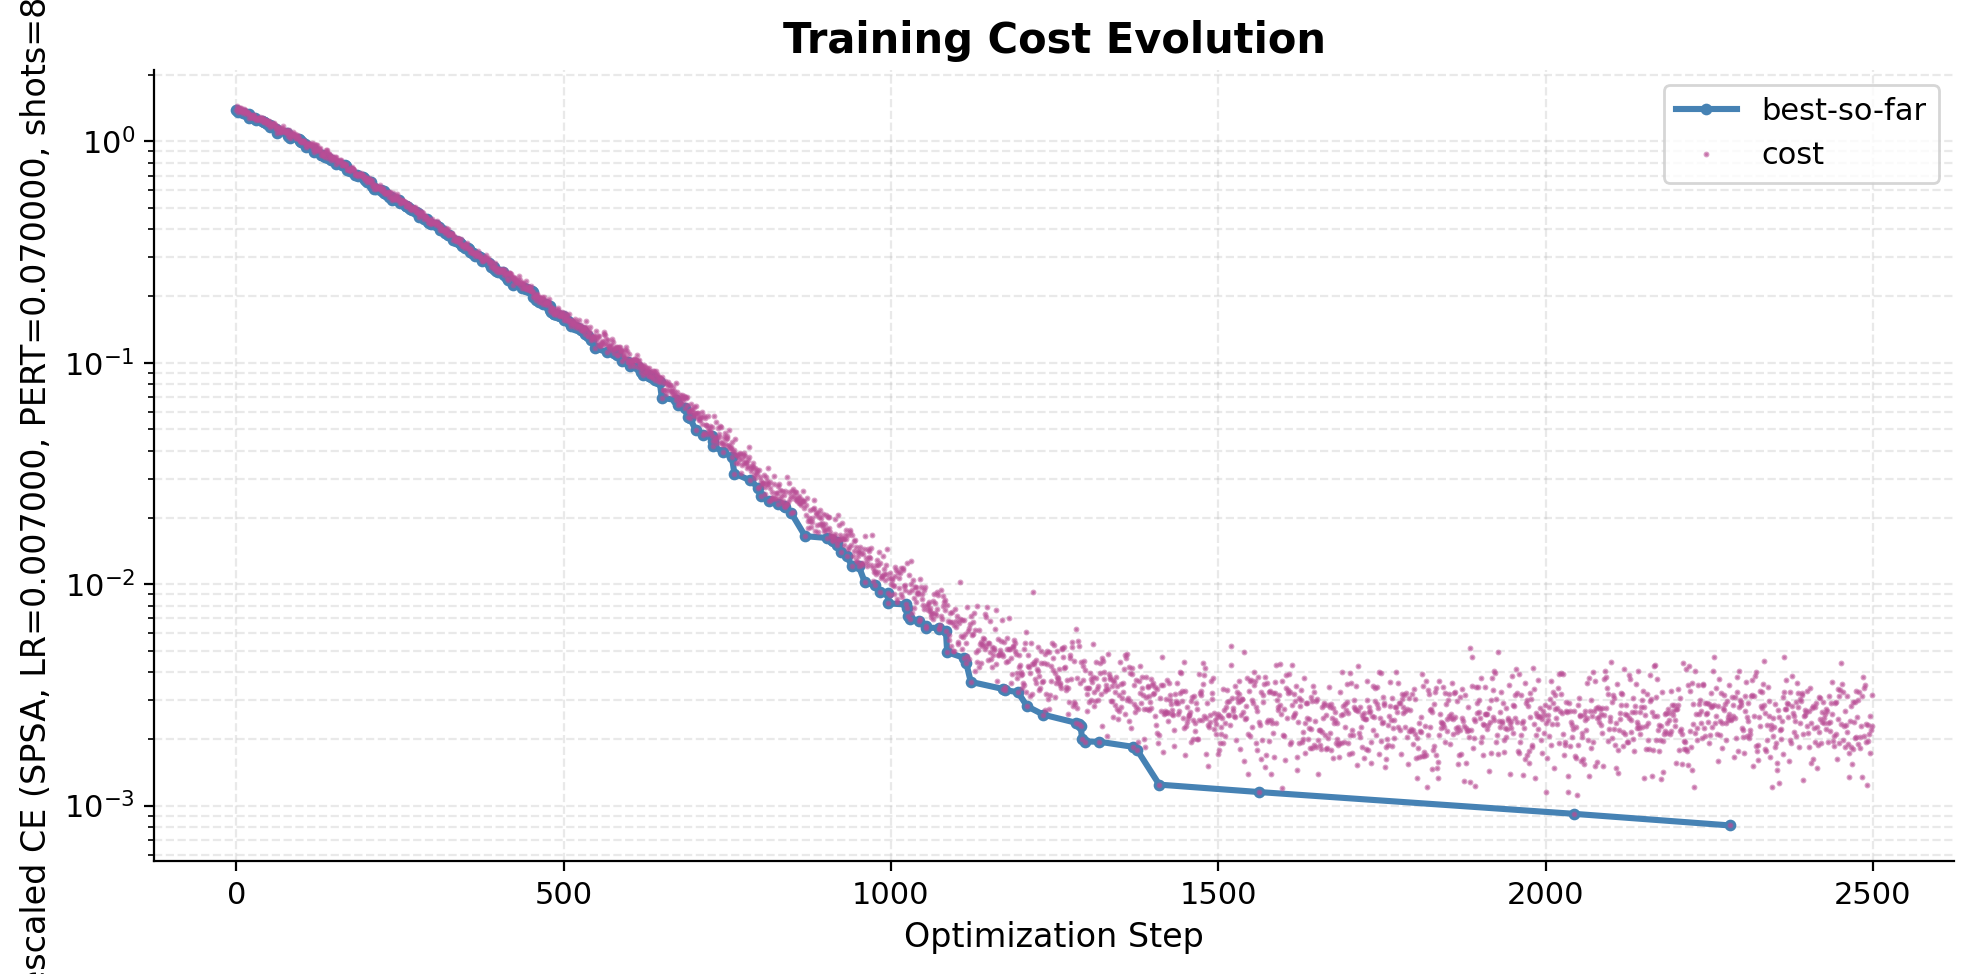

In [78]:
# -------------------------
# Diagnostics plot
# -------------------------
cost_history = np.asarray(cost_history, dtype=float)
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

p0_shots = qcbm.probabilities(theta0, shots=SHOTS, seed=None)
p_star_best = qcbm.probabilities(theta_best, shots=SHOTS, seed=None)

labels = [format(i, f"0{qcbm.n_qubits}b") for i in range(qcbm.dim)]
plot_training_diagnostics(
    target=ptg,
    before=p0_shots,
    after=p_star_best,
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Computational basis state |x⟩",
    ylabel="Probability",
    cost_ylabel=f"Rescaled CE (SPSA, LR={LR:.6f}, PERT={PERT:.6f}, shots={SHOTS})",
    title_before="Before training (QCBM, SPSA shot-based)",
    title_after="After training (best-iter, QCBM, SPSA shot-based)",
    cost_log_x=False,
    cost_log_y=True,
)
plt.show()

In [88]:
# -------------------------
# Metrics: evaluate fit quality (shot-based training)
# -------------------------
# Use shot-based probabilities for metric evaluation
p_star_shots = qcbm.probabilities(theta_best, shots=SHOTS, seed=101)

ms = qcbm.metrics(ptg, p_star_shots)

print("=== FIT METRICS (SPSA shot-based training, shot-based eval) ===")
print(f"KL(ptg || p*)  = {float(ms['kl'])}")
print(f"L1             = {float(ms['l1']):.6e}")
print(f"TV = 0.5*L1    = {float(ms['tv']):.6e}")
print(f"Linf           = {float(ms['linf']):.6e}")

print("\n=== Training summary ===")
print(f"Best cost observed: {best['fx']:.6f}")
print(f"Optimizer: SPSA (LR={LR:.4g}, PERT={PERT:.4g})")
print(f"Shots: {SHOTS}, Iterations: {N_ITERS}")

print("\n=== Target vs Trained distribution ===")
print("ptg (target):")
print(ptg.reshape(M, N))
print("\np_star (trained, shot-based):")
print(p_star_shots.reshape(M, N))

=== FIT METRICS (SPSA shot-based training, shot-based eval) ===
KL(ptg || p*)  = 0.002332526475510638
L1             = 2.616873e-02
TV = 0.5*L1    = 1.308437e-02
Linf           = 7.578681e-03

=== Training summary ===
Best cost observed: 0.000813
Optimizer: SPSA (LR=0.007, PERT=0.07)
Shots: 8000, Iterations: 7000

=== Target vs Trained distribution ===
ptg (target):
[[3.75000000e-07 1.42231000e-01 1.07759375e-01 9.25000000e-06]
 [8.21250411e-05 1.37796319e-01 1.11506931e-01 6.14625307e-04]
 [7.10520250e-04 1.35532363e-01 1.11066040e-01 2.69107670e-03]
 [2.10385889e-03 1.33253398e-01 1.08925553e-01 5.71718995e-03]]

p_star (trained, shot-based):
[[1.25000e-04 1.41875e-01 1.07875e-01 5.00000e-04]
 [2.50000e-04 1.45375e-01 1.06750e-01 2.50000e-04]
 [2.00000e-03 1.33375e-01 1.11875e-01 3.25000e-03]
 [1.62500e-03 1.30250e-01 1.10875e-01 3.75000e-03]]


Data saving

In [59]:
theta_best = np.asarray(best["x"], dtype=float).copy()

# --- Shot-based distribution ---
p_star_shots = qcbm.probabilities(theta_best, shots=SHOTS, seed=None)

metadata_shots = {
    # --- Model / target ---
    "model": "QCBM",
    "task": "joint_probability_state_prep",
    "order": getattr(ptg, "order", None),

    # --- Circuit ---
    "n_qubits": qcbm.n_qubits,
    "n_parameters": qcbm.n_params,

    # --- Optimizer ---
    "optimizer": "SPSA",
    "optimizer_library": "qiskit-algorithms",
    "learning_rate": float(LR),
    "perturbation": float(PERT),
    "epsilon": float(eps),
    "maxiter": int(N_ITERS),
    "resamplings": 1,
    "blocking": False,
    "trust_region": True,

    # --- Noise / objective ---
    "cost_function": "rescaled_cross_entropy",
    "shots": int(SHOTS),
    "stochastic_cost": True,

    # --- Best-iter info ---
    "trained_theta_is": "best_iter_observed",
    "best_iter_cost_observed": float(best.get("fx", np.nan)),

    # --- Hyperparam selection ---
    "hyperparam_selection": "SPSA coarse+refined grid (CV)",
    # --- Time --- #
    "training_time_seconds": float(_spsa_time),
}

npz_shots, json_shots = save_qcbm_distributions(
    qcbm=qcbm,
    p_trained=p_star_shots,
    p_target=ptg,
    filename_stem="qcbm_output_distribution_shots",
    subdir="data/qcbm",
    metadata=metadata_shots,
)

---